# Unsupervised Learning

# Install packages
Only run if you need to install packages

In [ ]:
%pip install rdkit
%pip install pandas
%pip install scikit-learn
%pip install matplotlib
%pip install numpy
%pip install umap-learn

# PCA and Unsupervised Learning
The PCA we discussed last time can also be used for unsupervised learning, clusters can sometimes be seen in the reduced data. We will look at this for reduced representation of molecular features

In [3]:
import pandas as pd

#load and look at data
df = pd.read_csv("pubchem_unsupervised_example.csv")
#sometimes data will have incorrect values, if they are supposed be a number but not they will often be annotated with NaN for
#not a number we can use dropna() to remove rows with NaN values
df = df.dropna()
df

,SMILES,MolecularFormula,MolecularWeight,IUPACName,XLogP,TPSA,HBondDonorCount,HBondAcceptorCount,RotatableBondCount,HeavyAtomCount,Complexity
0,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,C8H10N4O2,194.19,"1,3,7-trimethylpurine-2,6-dione",-0.1,58.4,0,3,0,14,293
1,CN1C2=C(C(=O)N(C1=O)C)NC=N2,C7H8N4O2,180.16,"1,3-dimethyl-7H-purine-2,6-dione",0.0,69.3,1,3,0,13,267
2,CN1C=NC2=C1C(=O)NC(=O)N2C,C7H8N4O2,180.16,"3,7-dimethylpurine-2,6-dione",-0.8,67.2,1,3,0,13,267
3,CN1C=NC2=C1C(=O)N(C(=O)N2)C,C7H8N4O2,180.16,"1,7-dimethyl-3H-purine-2,6-dione",-0.2,67.2,1,3,0,13,267
4,CN1C=NC2=C1C(=O)NC(=O)N2,C6H6N4O2,166.14,"7-methyl-3H-purine-2,6-dione",-0.9,76.0,2,3,0,12,242
...,...,...,...,...,...,...,...,...,...,...,...
360,C1=CC=C(C=C1)C2=CC(=NC(=C2)C3=NC(=CC=C3)C4=CC(...,C54H36N6,768.90,"4,6-bis[6-(4,6-diphenyl-2-pyridinyl)-2-pyridin...",11.0,77.3,0,6,9,60,1180
361,CC(C)C/C=C/CC1CCC2C1(CCC3=C2CCC4C3(CCC(=O)C4)C)C,C26H40O,368.60,"10,13-dimethyl-17-[(E)-5-methylhex-2-enyl]-1,2...",6.4,17.1,0,1,4,27,653
362,CCCCCCCCC=CCCCCCCCCCC(=O)OC1=C(C=C(C=C1OC)C2C3...,C41H56O8,676.90,"[2,6-dimethoxy-4-(6-oxo-5a,8,8a,9-tetrahydro-5...",11.5,89.5,0,8,22,49,1000
363,C[C@@H](C1=CC(=C(C=C1)Cl)Cl)[NH2+]CCCSC,C12H18Cl2NS+,279.20,"[(1S)-1-(3,4-dichlorophenyl)ethyl]-(3-methylsu...",4.0,41.9,1,1,6,16,192


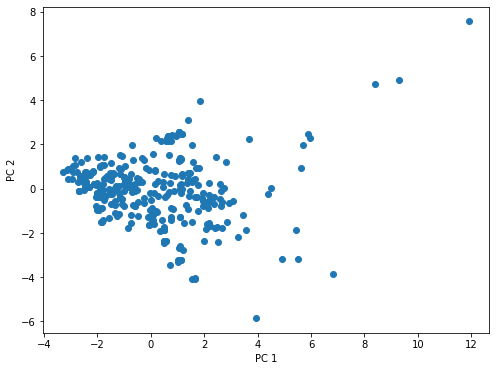

In [5]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

#assemble the pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),   
    ("pca", PCA(n_components=2))
])


reduced_data = pipe.fit_transform(df[["MolecularWeight","XLogP","TPSA","HBondDonorCount","HBondAcceptorCount","RotatableBondCount","HeavyAtomCount","Complexity"]])

plt.figure(figsize=(8, 6))
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.scatter(reduced_data[:,0],reduced_data[:,1])
plt.show()

# tSNE and UMAP
Compare the tSNE and UMAP results to PCA - which has more obvious clusters?
<br/>
Note that these methods have hyperparameters that will affect the result
<br/>
tSNE and UMAP can also be applied to fingerprints

In [10]:
#tSNE and UMAP applied to descriptors
from sklearn.manifold import TSNE
import umap

X_tsne = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(df[["MolecularWeight","XLogP","TPSA","HBondDonorCount","HBondAcceptorCount","RotatableBondCount","HeavyAtomCount","Complexity"]])
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:,0],X_tsne[:,1])
plt.title("tSNE on molecular descriptors")
plt.show()

X_umap = umap.UMAP(n_neighbors=5, random_state=42).fit(df[["MolecularWeight","XLogP","TPSA","HBondDonorCount","HBondAcceptorCount","RotatableBondCount","HeavyAtomCount","Complexity"]])
plt.figure(figsize=(8, 6))
plt.scatter(X_umap.embedding_[:,0],X_umap.embedding_[:,1])
plt.title("UMAP  on molecular descriptors")
plt.show()


ModuleNotFoundError: No module named 'umap'

In [11]:
from rdkit import Chem

#method we will use to convert fingerprint to an array that can be used later with scikit learn
def mol_to_fp_array(mol, radius=2, nBits=2048):
    if mol is None:
        return None
    
    fpgen_morgan = AllChem.GetMorganGenerator(radius=radius,fpSize=nBits)
    fp = fpgen_morgan.GetFingerprint(mol)
    
    arr = np.zeros((nBits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    return arr

df["mol"] = df["SMILES"].apply(Chem.MolFromSmiles)
df["fp"] = df["mol"].apply(lambda m: mol_to_fp_array(m) if m is not None else pd.NA)


X_tsne = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(df["fp"].values)
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:,0],X_tsne[:,1])
plt.title("tSNE on molecular descriptors")
plt.show()

X_umap = umap.UMAP(n_neighbors=5, random_state=42).fit(df["fp"].values)
plt.figure(figsize=(8, 6))
plt.scatter(X_umap.embedding_[:,0],X_umap.embedding_[:,1])
plt.title("UMAP  on molecular descriptors")
plt.show()


KeyError: 'mol'

# K-Means Clustering

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(df[["MolecularWeight","XLogP","TPSA","HBondDonorCount","HBondAcceptorCount","RotatableBondCount","HeavyAtomCount","Complexity"]])

plt.figure(figsize=(8, 6))
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.scatter(reduced_data[:,0],reduced_data[:,1],c=kmeans.labels_, cmap='viridis')
plt.show()


# Affinity Propagation

# DBSCAN and HDBSCAN

# Butina

# Metrics

# Choosing number of clusters with metrics